In [16]:
!pip install matplotlib seaborn wordcloud pandas

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [17]:
df = pd.read_csv("../data/final/secondary_ads_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (225261, 15)


,category,app_name,country,continent,review_id,review_date,rating,review_text,likes,reviewer_name,scraped_at,clean_text,ad_mentioned,ad_keyword,sentiment
0,Social Media,Instagram,us,North America,e3b1e0ac-69b8-4607-b76c-9847eeaf0e4e,2026-03-11 23:58:06,1,very nice app,0,KhushbooRani Khushboo,2026-03-13 00:02:03.924872,nice app,0,none,positive
1,Social Media,Instagram,us,North America,5157f955-0034-4dec-a286-848441463191,2026-03-11 23:58:02,5,Really helps getting to know other people's li...,0,Sena Risk,2026-03-13 00:02:03.924884,really help getting know people lifestyle ou,0,none,positive
2,Social Media,Instagram,us,North America,a53ce01c-3c11-4a43-a5b7-e20ef80b56f6,2026-03-11 23:57:48,5,this one,0,Ankit Saini,2026-03-13 00:02:03.924886,one,0,none,neutral
3,Social Media,Instagram,us,North America,454407b1-e1a6-4f9b-8485-39ffa412b563,2026-03-11 23:56:29,1,not good for use..,0,Pavan Bidve,2026-03-13 00:02:03.924888,good use,0,none,positive
4,Social Media,Instagram,us,North America,262f9eec-8c03-4728-8d7b-03d38008182f,2026-03-11 23:56:10,5,very good 💯 👌🏻👍🏻,0,vandana kashyap,2026-03-13 00:02:03.924890,good,0,none,positive


In [18]:
print("Columns in Dataset:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Columns in Dataset:
Index(['category', 'app_name', 'country', 'continent', 'review_id',
       'review_date', 'rating', 'review_text', 'likes', 'reviewer_name',
       'scraped_at', 'clean_text', 'ad_mentioned', 'ad_keyword', 'sentiment'],
      dtype='object')

Missing Values:
category         0
app_name         0
country          0
continent        0
review_id        0
review_date      0
rating           0
review_text      0
likes            0
reviewer_name    0
scraped_at       0
clean_text       0
ad_mentioned     0
ad_keyword       0
sentiment        0
dtype: int64

Basic Statistics:
              rating          likes   ad_mentioned
count  225261.000000  225261.000000  225261.000000
mean        3.631050       1.677885       0.176342
std         1.730616      27.935961       0.381112
min         1.000000       0.000000       0.000000
25%         1.000000       0.000000       0.000000
50%         5.000000       0.000000       0.000000
75%         5.000000       0.000000       0.000

/var/folders/z7/4zbkkbkd4xzc1m0hkwzwjck00000gn/T/ipykernel_22803/490628355.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", palette="coolwarm")


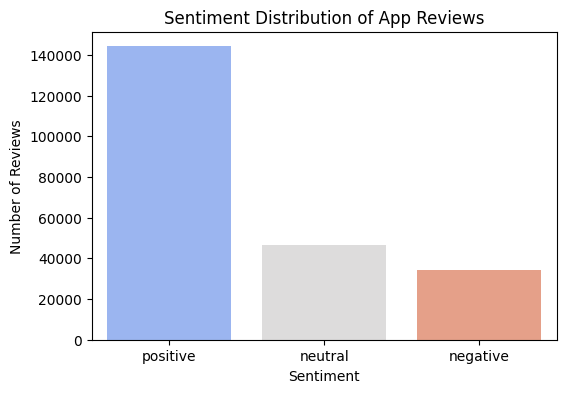

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sentiment", palette="coolwarm")

plt.title("Sentiment Distribution of App Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

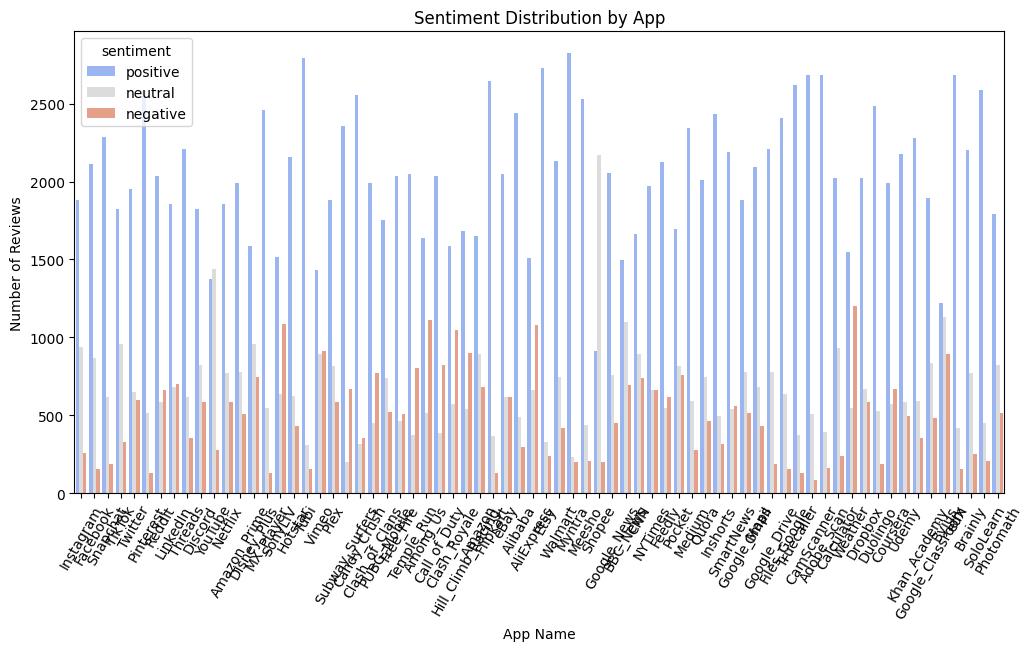

In [20]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="app_name",
    hue="sentiment",
    palette="coolwarm"
)

plt.xticks(rotation=60)

plt.title("Sentiment Distribution by App")
plt.xlabel("App Name")
plt.ylabel("Number of Reviews")

plt.show()

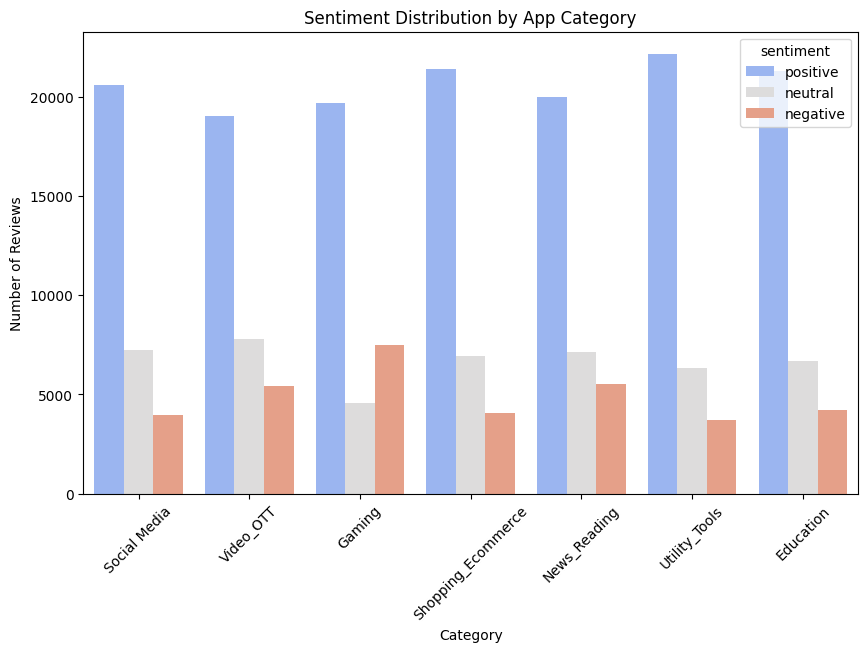

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="category",
    hue="sentiment",
    palette="coolwarm"
)

plt.xticks(rotation=45)

plt.title("Sentiment Distribution by App Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.show()

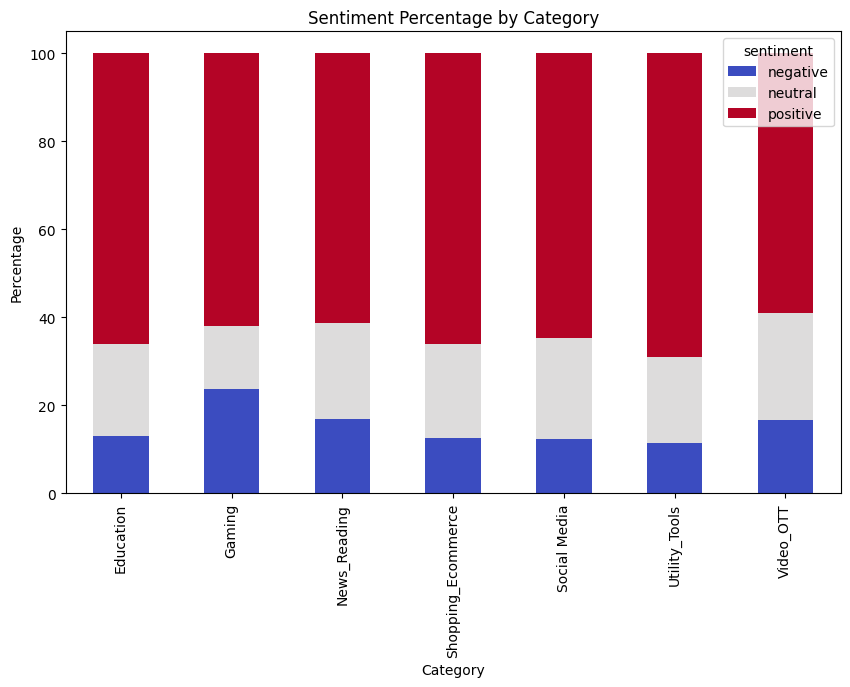

In [22]:
category_sentiment = pd.crosstab(
    df["category"],
    df["sentiment"],
    normalize="index"
) * 100

category_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="coolwarm"
)

plt.title("Sentiment Percentage by Category")
plt.ylabel("Percentage")
plt.xlabel("Category")

plt.show()

/var/folders/z7/4zbkkbkd4xzc1m0hkwzwjck00000gn/T/ipykernel_22803/322014765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="ad_mentioned", palette="viridis")


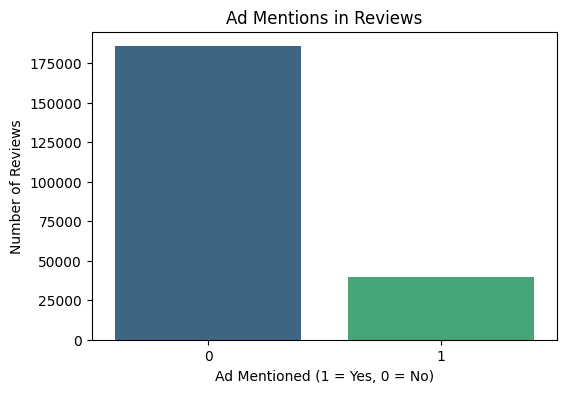

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="ad_mentioned", palette="viridis")

plt.title("Ad Mentions in Reviews")
plt.xlabel("Ad Mentioned (1 = Yes, 0 = No)")
plt.ylabel("Number of Reviews")

plt.show()

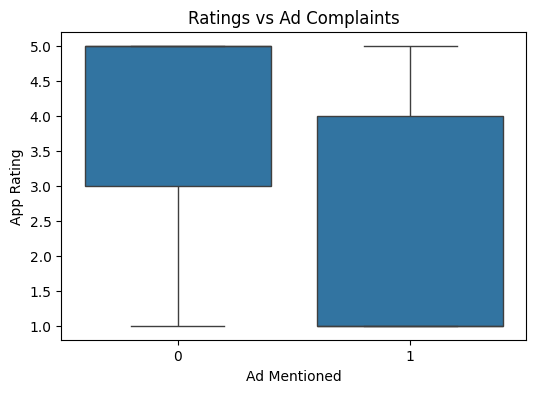

In [24]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="ad_mentioned", y="rating")

plt.title("Ratings vs Ad Complaints")
plt.xlabel("Ad Mentioned")
plt.ylabel("App Rating")

plt.show()

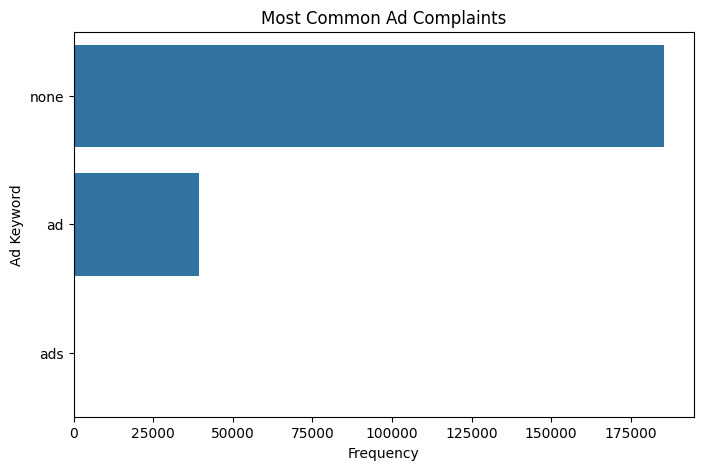

In [25]:
keyword_counts = df["ad_keyword"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=keyword_counts.values, y=keyword_counts.index)

plt.title("Most Common Ad Complaints")
plt.xlabel("Frequency")
plt.ylabel("Ad Keyword")

plt.show()

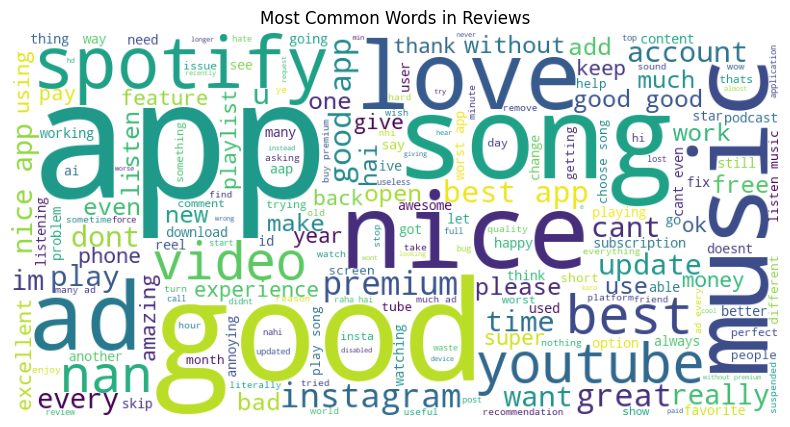

In [13]:
text = " ".join(df["clean_text"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

plt.title("Most Common Words in Reviews")

plt.show()

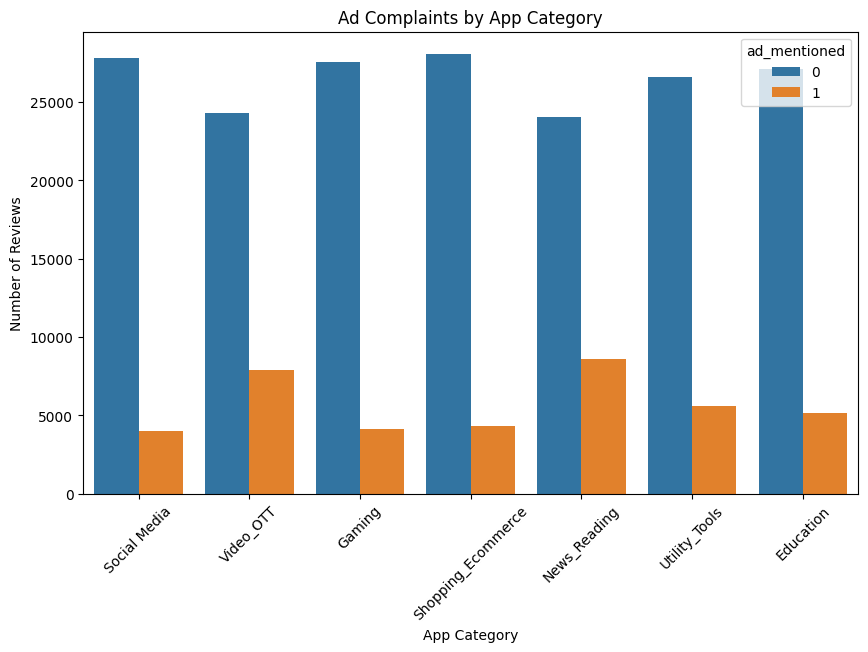

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="category", hue="ad_mentioned")

plt.xticks(rotation=45)

plt.title("Ad Complaints by App Category")
plt.xlabel("App Category")
plt.ylabel("Number of Reviews")

plt.show()

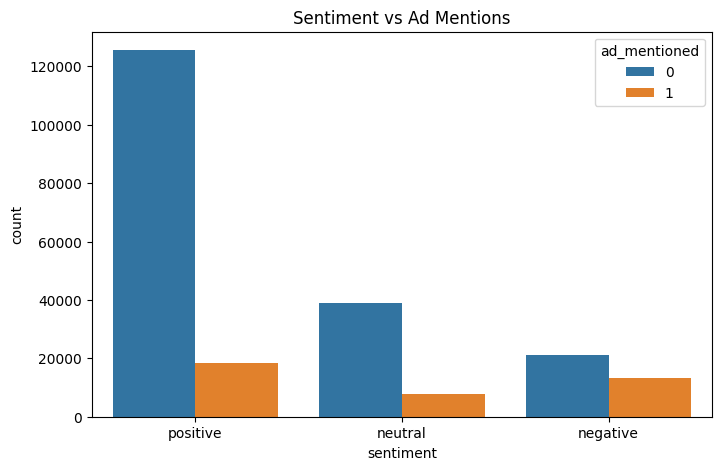

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="sentiment", hue="ad_mentioned")

plt.title("Sentiment vs Ad Mentions")

plt.show()

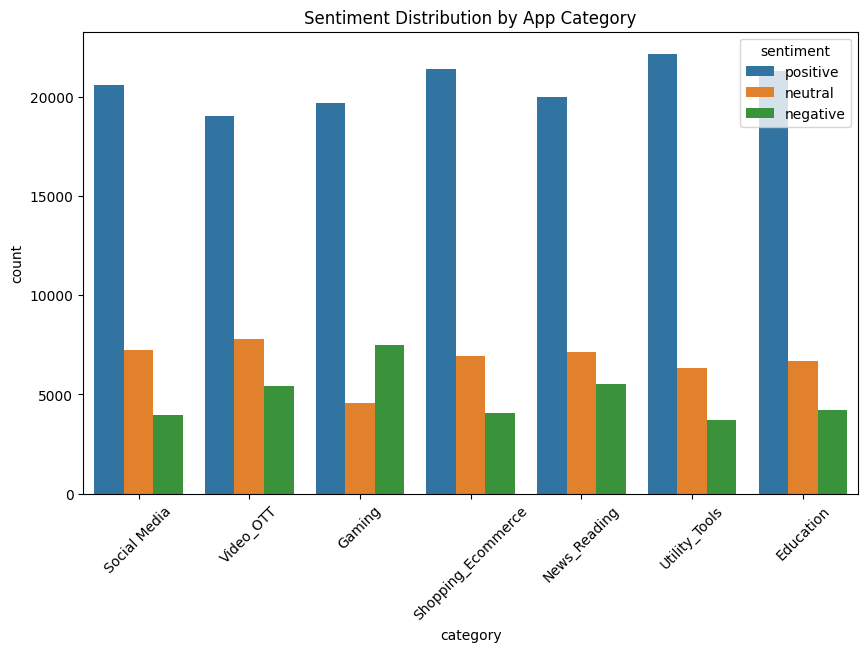

In [28]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="category", hue="sentiment")

plt.xticks(rotation=45)

plt.title("Sentiment Distribution by App Category")

plt.show()

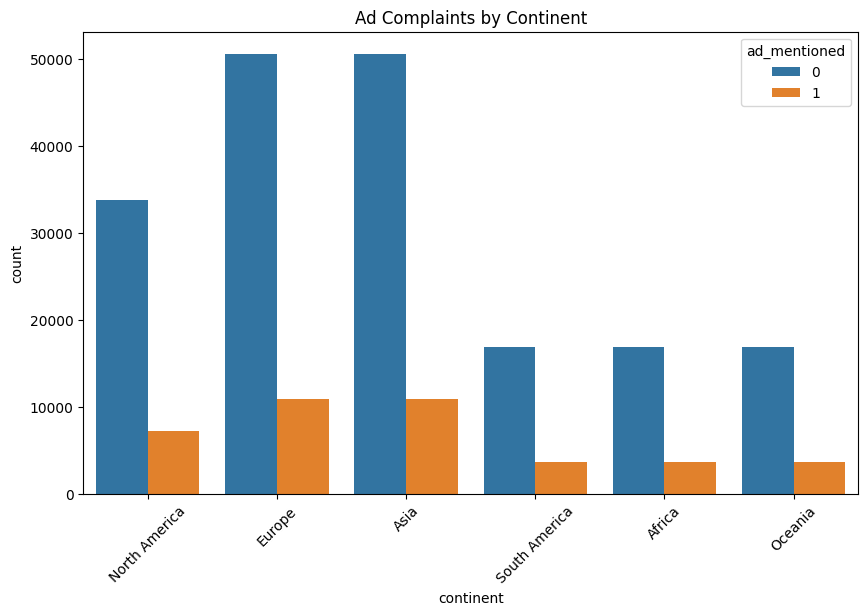

In [29]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="continent", hue="ad_mentioned")

plt.xticks(rotation=45)

plt.title("Ad Complaints by Continent")

plt.show()

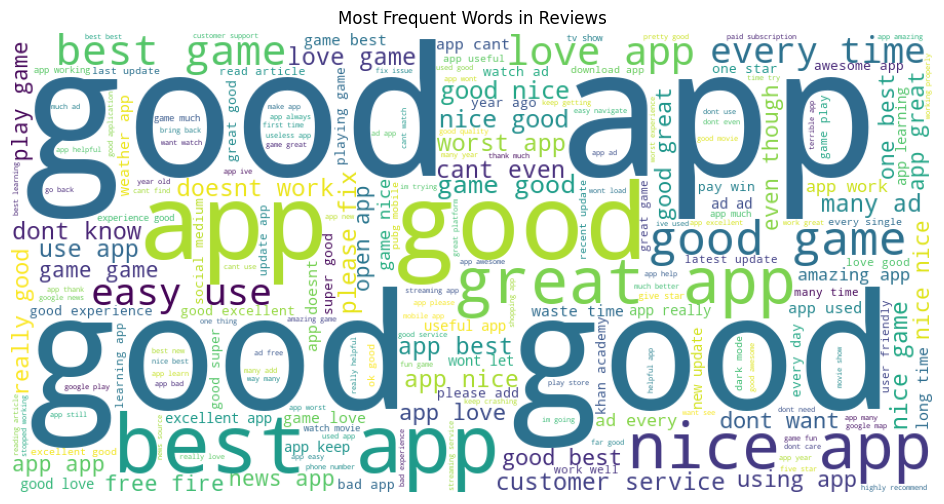

In [30]:
text = " ".join(df["clean_text"].astype(str))

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")

plt.title("Most Frequent Words in Reviews")

plt.show()

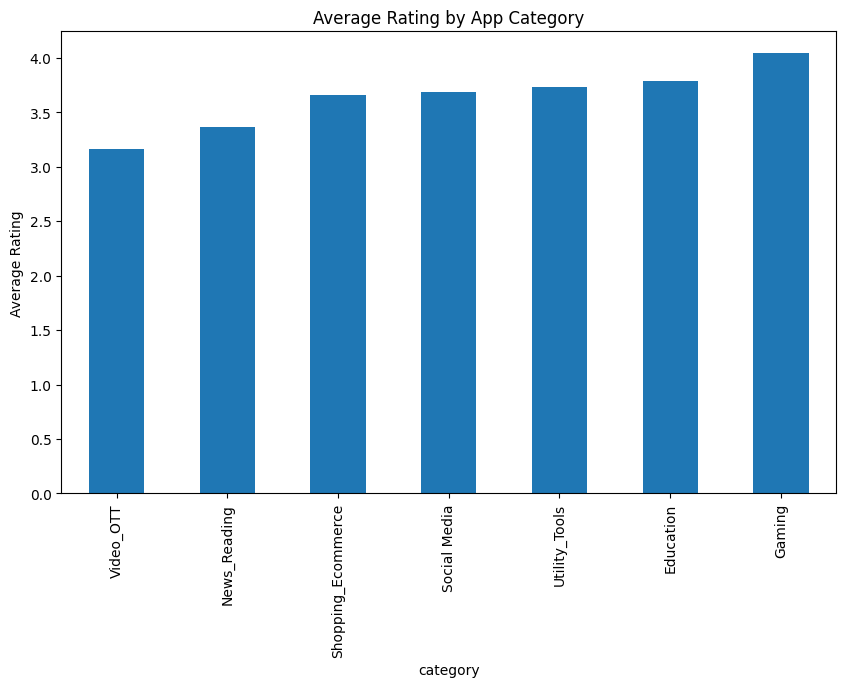

In [31]:
category_rating = df.groupby("category")["rating"].mean().sort_values()

plt.figure(figsize=(10,6))

category_rating.plot(kind="bar")

plt.title("Average Rating by App Category")
plt.ylabel("Average Rating")

plt.show()

In [32]:
dashboard_df = df[[
    "category",
    "app_name",
    "continent",
    "rating",
    "sentiment",
    "ad_mentioned",
    "ad_keyword"
]]

dashboard_df.to_csv("../dashboard/dashboard_dataset.csv", index=False)

print("Dashboard dataset saved successfully")

Dashboard dataset saved successfully


In [33]:
print("Top Ad Complaints:")
print(df["ad_keyword"].value_counts().head(10))

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nAverage Rating:")
print(df["rating"].mean())

Top Ad Complaints:
ad_keyword
none    185538
ad       39239
ads        484
Name: count, dtype: int64

Sentiment Distribution:
sentiment
positive    144159
neutral      46704
negative     34398
Name: count, dtype: int64

Average Rating:
3.6310502039855987
